# MNIST

Loads the MNIST digits into numpy / torch for the embedding-inversion experiments.

The dataset lives in `data/mnist/` (gitignored). The download cell checks md5s and
skips anything already on disk, so re-running the notebook is cheap.

torchvision isn't used: there's no torchvision wheel built against this env's
torch 2.14+cpu, so `mnist.py` pulls the raw idx.gz files instead.

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

import mnist

torch.manual_seed(0)
np.random.seed(0)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| numpy", np.__version__, "| device", DEVICE)

torch 2.14.0+cpu | numpy 2.5.3 | device cpu


## Download

No-op if the four archives are already present and intact.

In [2]:
root = mnist.download()
print("data at", root)

skip     train-images-idx3-ubyte.gz (already downloaded)
skip     train-labels-idx1-ubyte.gz (already downloaded)
skip     t10k-images-idx3-ubyte.gz (already downloaded)
skip     t10k-labels-idx1-ubyte.gz (already downloaded)
data at /home/dmmsp/Projects/ReversingEmbeddings/data/mnist


## Load

In [3]:
train_x, train_y = mnist.load("train")   # uint8 [N, 28, 28], uint8 [N]
test_x,  test_y  = mnist.load("test")

print("train", train_x.shape, train_y.shape)
print("test ", test_x.shape, test_y.shape)
print("pixel range", train_x.min(), "-", train_x.max())
print("class counts", np.bincount(train_y))

train (60000, 28, 28) (60000,)
test  (10000, 28, 28) (10000,)
pixel range 0 - 255
class counts [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


## Tensors

Scaled to [0, 1] and normalised by the usual MNIST mean/std. `*_flat` is the
[N, 784] view, which is what the inversion code wants.

In [4]:
MEAN, STD = 0.1307, 0.3081

def to_tensor(x, y):
    imgs = torch.from_numpy(x.copy()).float().div_(255.0)
    imgs = (imgs - MEAN) / STD
    return imgs.unsqueeze(1), torch.from_numpy(y.copy()).long()   # [N,1,28,28], [N]

train_imgs, train_labels = to_tensor(train_x, train_y)
test_imgs,  test_labels  = to_tensor(test_x, test_y)

train_flat = train_imgs.view(len(train_imgs), -1)
test_flat  = test_imgs.view(len(test_imgs), -1)

print(train_imgs.shape, train_imgs.dtype, "| flat", train_flat.shape)
print(f"normalised mean {train_imgs.mean():.4f}  std {train_imgs.std():.4f}")

torch.Size([60000, 1, 28, 28]) torch.float32 | flat torch.Size([60000, 784])


normalised mean -0.0001  std 1.0000


## A look at the digits

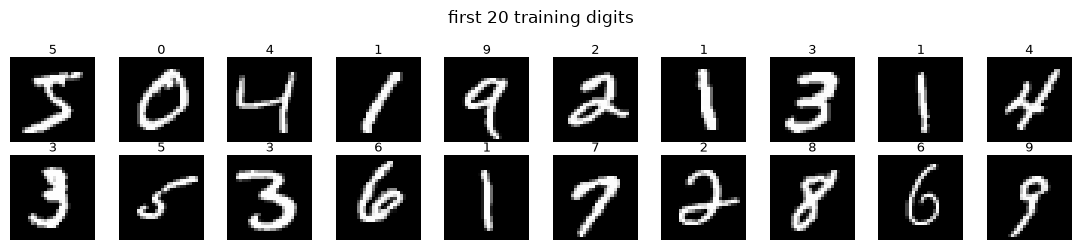

In [5]:
def show(imgs, labels, n=10, cols=10, title=None):
    """imgs: [N,1,28,28] normalised tensor or [N,28,28] uint8 array."""
    if torch.is_tensor(imgs):
        arr = (imgs[:n].squeeze(1) * STD + MEAN).clamp(0, 1).numpy()
    else:
        arr = imgs[:n] / 255.0
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.1, rows * 1.25))
    for ax, img, lab in zip(np.ravel(axes), arr, labels[:n]):
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        ax.set_title(int(lab), fontsize=9, pad=2)
    for ax in np.ravel(axes):
        ax.axis("off")
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    plt.show()

show(train_imgs, train_labels, n=20, title="first 20 training digits")

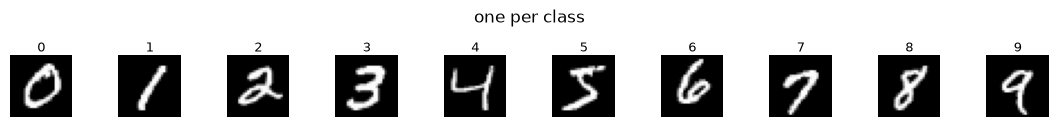

In [6]:
# one example of each class
idx = [int(np.where(train_y == d)[0][0]) for d in range(10)]
show(train_imgs[idx], train_labels[idx], n=10, title="one per class")

## Batching

Plain `TensorDataset` + `DataLoader`; no torchvision transforms in the loop.

In [7]:
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(train_imgs, train_labels)
test_ds  = TensorDataset(test_imgs,  test_labels)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

xb, yb = next(iter(train_loader))
print("batch", xb.shape, yb.shape, "|", len(train_loader), "train batches")

batch torch.Size([128, 1, 28, 28]) torch.Size([128]) | 468 train batches
